Setup Python Environment

In [2]:
pip install pandas

Load the Data

In [4]:
import pandas as pd

df = pd.read_csv('sales_data.csv')

# Show first rows
print(df.head())

   Order_ID        Date Region     Category     Product   Sales  Quantity  \
0       101  2025-10-12  North  Electronics      Laptop  120000         1   
1       102  2025-10-15  South    Furniture       Chair    8500         4   
2       103  2025-10-20   East  Electronics  Smartphone   45000         2   
3       104  2025-11-05  North    Furniture        Desk   25000         1   
4       105  2025-11-12   West  Electronics      Laptop  120000         1   

   Profit  
0   15000  
1    1200  
2    8000  
3    -500  
4   15000  


Understanding Data

In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  10 non-null     int64 
 1   Date      10 non-null     object
 2   Region    10 non-null     object
 3   Category  10 non-null     object
 4   Product   10 non-null     object
 5   Sales     10 non-null     int64 
 6   Quantity  10 non-null     int64 
 7   Profit    10 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 772.0+ bytes
None
        Order_ID          Sales   Quantity        Profit
count   10.00000      10.000000  10.000000     10.000000
mean   105.50000   48370.000000   7.500000   6170.000000
std      3.02765   51450.754233  15.182226   6745.047566
min    101.00000     500.000000   1.000000   -500.000000
25%    103.25000    8500.000000   1.000000    375.000000
50%    105.50000   30000.000000   2.000000   4100.000000
75%    107.75000  101250.000000   3.750000  13250.000000
max

Find Highest Profitable Product

In [6]:
top_product = df.groupby('Product')['Profit'].sum().idxmax()
top_profit = df.groupby('Product')['Profit'].sum().max()

print("Top Product:", top_product)
print("Total Profit:", top_profit)

Top Product: Laptop
Total Profit: 45000


Create Pivot Table

In [8]:
pivot_table = pd.pivot_table(
    df,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

print(pivot_table)

Category  Electronics  Furniture  Office
Region                                  
East          45000.0     8500.0     NaN
North        120000.0    25000.0   500.0
South        120000.0     8500.0  1200.0
West         155000.0        NaN     NaN


Create "Status" Column

In [9]:
def check_status(profit):
    if profit > 5000:
        return "High Margin"
    elif profit < 0:
        return "Review Required"
    else:
        return "Normal"

df['Status'] = df['Profit'].apply(check_status)

print(df)

   Order_ID        Date Region     Category     Product   Sales  Quantity  \
0       101  2025-10-12  North  Electronics      Laptop  120000         1   
1       102  2025-10-15  South    Furniture       Chair    8500         4   
2       103  2025-10-20   East  Electronics  Smartphone   45000         2   
3       104  2025-11-05  North    Furniture        Desk   25000         1   
4       105  2025-11-12   West  Electronics      Laptop  120000         1   
5       106  2025-11-20  South       Office       Paper    1200        10   
6       107  2025-12-01   East    Furniture       Chair    8500         2   
7       108  2025-12-15  North       Office         Pen     500        50   
8       109  2025-12-20   West  Electronics      Tablet   35000         3   
9       110  2026-01-05  South  Electronics      Laptop  120000         1   

   Profit           Status  
0   15000      High Margin  
1    1200           Normal  
2    8000      High Margin  
3    -500  Review Required  
4   150

Save Final Output

In [10]:
df.to_csv('final_sales_report.csv', index=False)
pivot_table.to_csv('pivot_report.csv')

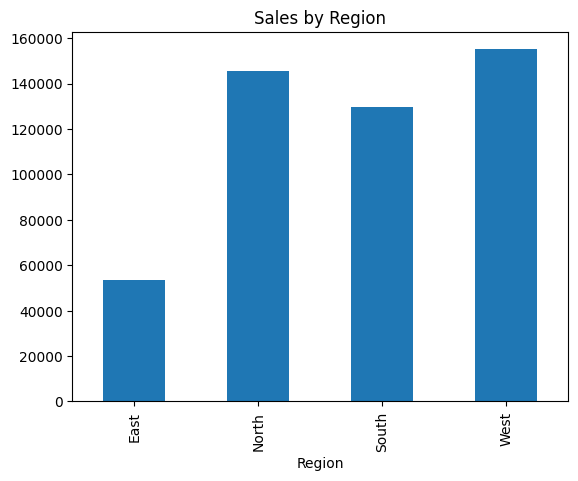

In [11]:
import matplotlib.pyplot as plt

df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

In [12]:
print("\n=== EXECUTIVE SUMMARY ===")
print("Top Product:", top_product)
print("\nPivot Table:\n", pivot_table)


=== EXECUTIVE SUMMARY ===
Top Product: Laptop

Pivot Table:
 Category  Electronics  Furniture  Office
Region                                  
East          45000.0     8500.0     NaN
North        120000.0    25000.0   500.0
South        120000.0     8500.0  1200.0
West         155000.0        NaN     NaN
